In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files

uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import os

print(os.listdir())

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D")

drugs = [
    "Paracetamol", "Amoxicillin", "Azithromycin", "Ibuprofen",
    "Cetirizine", "Omeprazole", "Metformin", "Amlodipine",
    "Atorvastatin", "Pantoprazole"
]

categories = [
    "Branded", "Generic", "Branded", "Generic",
    "Generic", "Branded", "Generic", "Branded",
    "Branded", "Generic"
]

data = []

for i in range(1000):
    drug_index = np.random.randint(0, len(drugs))
    quantity = np.random.randint(1, 21)
    price = round(np.random.uniform(2, 50), 2)

    data.append([
        np.random.choice(dates),
        drugs[drug_index],
        categories[drug_index],
        quantity,
        price,
        round(quantity * price, 2)
    ])

df = pd.DataFrame(
    data,
    columns=[
        "Date",
        "Drug Name",
        "Category",
        "Quantity",
        "Price (USD)",
        "Sales (USD)"
    ]
)

df.head()

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "Date": pd.date_range("2025-01-01", periods=1000),
    "Drug Name": np.random.choice(
        ["Paracetamol", "Amoxicillin", "Azithromycin", "Ibuprofen", "Cetirizine"],
        1000
    ),
    "Category": np.random.choice(["Branded", "Generic"], 1000),
    "Quantity": np.random.randint(1, 21, 1000),
    "Price (USD)": np.round(np.random.uniform(2, 50, 1000), 2)
})

df["Sales (USD)"] = df["Quantity"] * df["Price (USD)"]

df.head()

,Date,Drug Name,Category,Quantity,Price (USD),Sales (USD)
0,2025-01-01,Ibuprofen,Generic,12,32.46,389.52
1,2025-01-02,Cetirizine,Generic,17,40.30,685.10
2,2025-01-03,Azithromycin,Generic,8,21.01,168.08
3,2025-01-04,Cetirizine,Generic,11,45.92,505.12
4,2025-01-05,Cetirizine,Generic,3,27.59,82.77


In [6]:
df.shape

(1000, 6)

In [7]:
df.isnull().sum()

,0
Date,0
Drug Name,0
Category,0
Quantity,0
Price (USD),0
Sales (USD),0


In [8]:
total_sales = df["Sales (USD)"].sum()
total_sales

np.float64(274176.97)

In [9]:
total_quantity = df["Quantity"].sum()
total_quantity

np.int64(10455)

In [10]:
total_orders = len(df)
total_orders

1000

In [11]:
average_order_value = total_sales / total_orders
average_order_value

np.float64(274.17697)

In [12]:
top_drugs = df.groupby("Drug Name")["Sales (USD)"].sum().sort_values(ascending=False)

top_drugs.head(5)

,Sales (USD)
Drug Name,
Cetirizine,60738.65
Paracetamol,56923.59
Ibuprofen,55310.03
Azithromycin,53216.86
Amoxicillin,47987.84


In [13]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales (USD)"].sum()

monthly_sales

,Sales (USD)
Date,
2025-01,9907.38
2025-02,8934.47
2025-03,8467.11
2025-04,7296.75
2025-05,8757.67
2025-06,9565.61
2025-07,6348.71
2025-08,7229.43
2025-09,6397.36


In [14]:
df = df[df["Date"].dt.year == 2025].copy()

df.shape

(365, 6)

In [15]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Sales (USD)"].sum()

monthly_sales

,Sales (USD)
Date,
2025-01,9907.38
2025-02,8934.47
2025-03,8467.11
2025-04,7296.75
2025-05,8757.67
2025-06,9565.61
2025-07,6348.71
2025-08,7229.43
2025-09,6397.36


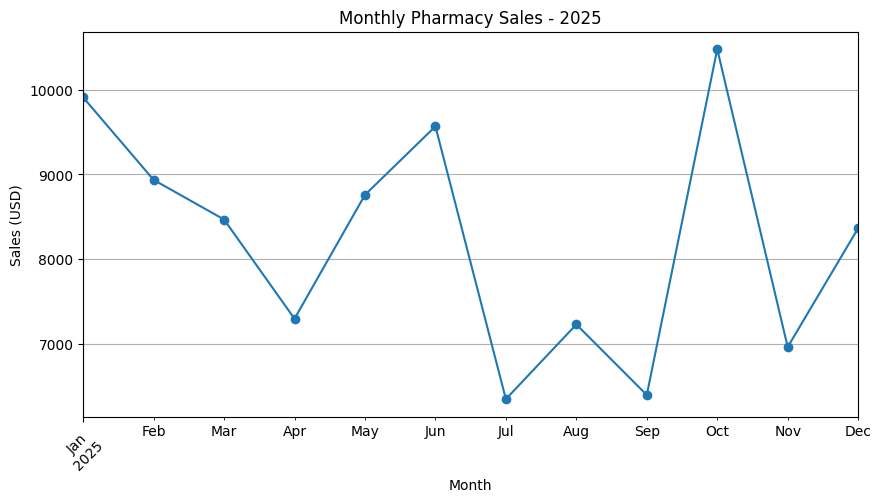

In [16]:
import matplotlib.pyplot as plt

monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Pharmacy Sales - 2025")
plt.xlabel("Month")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [17]:
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth

,Sales (USD)
Date,
2025-01,NaN
2025-02,-9.820053
2025-03,-5.230976
2025-04,-13.822426
2025-05,20.021516
2025-06,9.225513
2025-07,-33.629847
2025-08,13.872424
2025-09,-11.509483


In [18]:
category_sales = df.groupby("Category")["Sales (USD)"].sum()

category_sales

,Sales (USD)
Category,
Branded,51774.63
Generic,46934.09


In [19]:
category_quantity = df.groupby("Category")["Quantity"].sum()

category_quantity

,Quantity
Category,
Branded,1953
Generic,1879


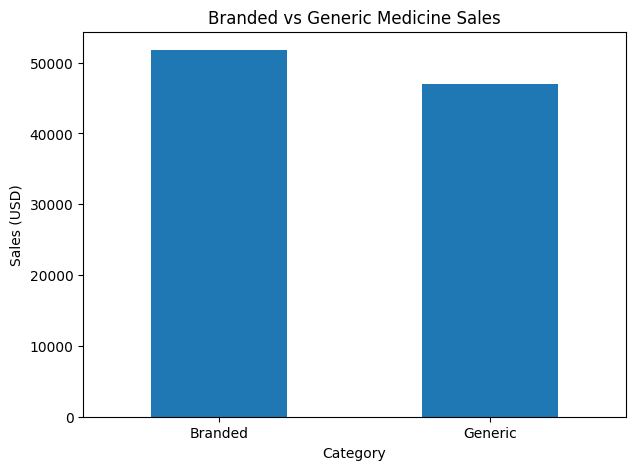

In [20]:
category_sales.plot(kind="bar", figsize=(7,5))

plt.title("Branded vs Generic Medicine Sales")
plt.xlabel("Category")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=0)
plt.show()

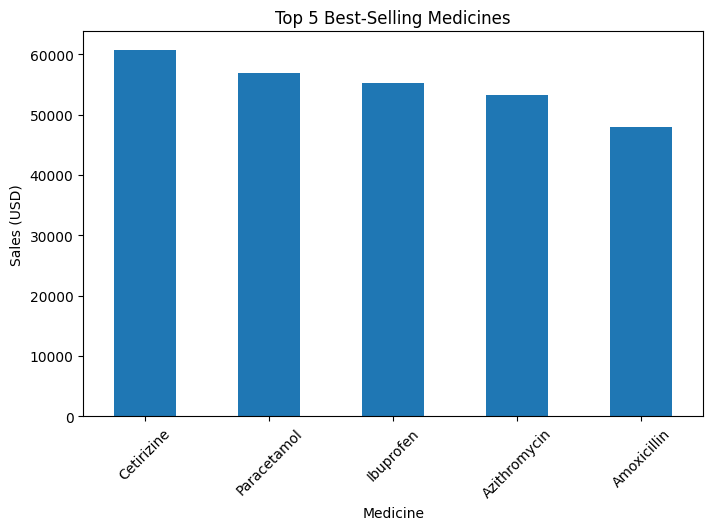

In [22]:
top_5 = top_drugs.head(5)

top_5.plot(kind="bar", figsize=(8,5))

plt.title("Top 5 Best-Selling Medicines")
plt.xlabel("Medicine")
plt.ylabel("Sales (USD)")
plt.xticks(rotation=45)
plt.show()

## Task 3: Pharmacy Sales Analysis – Key Insights

- Total sales generated in 2025 were approximately USD 98,708.72.
- A total of 3,832 medicine units were sold across 365 orders.
- The average order value was approximately USD 270.43.
- Cetirizine recorded the highest sales among the medicines analyzed.
- October showed the highest monthly sales growth compared with September.
- July experienced the largest monthly decline in sales compared with June.
- Branded medicines generated higher sales and quantity than generic medicines in this dataset.
- The analysis helps identify medicine sales trends, monthly performance, and differences between branded and generic products.
